# Pycaret

## import libraries and load data

In [ ]:
from pycaret.time_series import get_config

pip install lime

In [ ]:
pip install pycaret[analysis]

In [ ]:
pip install pandas

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from pycaret.regression import setup, compare_models, pull, predict_model, save_model
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Visualisations
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib import cm
import os
import shap

# Model building
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lime.lime_tabular

In [2]:
import csv

from pathlib import Path

In [3]:
from pycaret.regression import setup, compare_models, interpret_model, plot_model, dashboard

In [5]:
import explainerdashboard

In [6]:
file_path = Path("C:/Users/lodeg/PyCharmMiscProject/Cars_Datasets_2025_FE (1).csv")
file_path_2 = Path("C:/Users/lodeg/PyCharmMiscProject/Cars Datasets 2025 cleaned.csv")
file_path_3 = Path("C:/Users/lodeg/PyCharmMiscProject/dfp.csv")

# Read CSV file into Spark DataFrame
df_FE = pd.read_csv(file_path)
df_cleaned = pd.read_csv(file_path_2)
dfp = pd.read_csv(file_path_3)

# Display basic information
display(df_FE)
display(df_cleaned)

,company_names,cars_names,Engines,cc_battery_capacity,HorsePower,total_speed,performance_0_100_kmh,cars_prices,fuel_types,Seats,Torque,HP_per_CC,Price_per_HP,HP_Acceleration_Effectiveness,Price_per_Seat,Cylinders,Price_Category
0,FORD,KA+,1.2L Petrol,1200,77,165,10.50,13500,Petrol,5,120,0.064167,175.324675,7.333333,2700.000000,4,Budget
1,TOYOTA,GR SUPRA,I4,2998,382,250,4.10,53900,Petrol,2,500,0.127418,141.099476,93.170732,26950.000000,4,Luxury
2,TOYOTA,TOYOTA 86,BOXER-4,1998,205,226,6.40,27000,Petrol,2,205,0.102603,131.707317,32.031250,13500.000000,4,Mid-Range
3,TOYOTA,TOYOTA GR86,BOXER-4,2387,228,226,5.60,30000,Petrol,4,250,0.095517,131.578947,40.714286,7500.000000,4,Mid-Range
4,TOYOTA,TOYOTA LAND CRUISER,V8,5663,381,220,6.70,85000,Diesel,7,500,0.067279,223.097113,56.865672,12142.857143,8,Luxury
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1038,TOYOTA,Crown Signia,2.5L Hybrid I4,2487,240,180,7.60,45795,Hybrid,5,239,0.096502,190.812500,31.578947,9159.000000,4,Mid-Range
1039,TOYOTA,4Runner (6th Gen),2.4L Turbo I4 (i-FORCE MAX Hybrid),2393,326,180,6.80,50000,Hybrid,7,630,0.136231,153.374233,47.941176,7142.857143,4,Mid-Range
1040,TOYOTA,Corolla Cross,2.0L Gas / 2.0L Hybrid,1987,182,190,8.60,27172,Hybrid,5,200,0.091595,149.296703,21.162791,5434.400000,4,Mid-Range
1041,TOYOTA,C-HR+,1.8L / 2.0L Hybrid,1892,169,180,9.20,33000,Hybrid,5,197,0.089323,195.266272,18.369565,6600.000000,4,Mid-Range


,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FORD,KA+,1.2L Petrol,1200,77,165,10.50,13500,Petrol,5,120
1,TOYOTA,GR SUPRA,I4,2998,382,250,4.10,53900,Petrol,2,500
2,TOYOTA,TOYOTA 86,BOXER-4,1998,205,226,6.40,27000,Petrol,2,205
3,TOYOTA,TOYOTA GR86,BOXER-4,2387,228,226,5.60,30000,Petrol,4,250
4,TOYOTA,TOYOTA LAND CRUISER,V8,5663,381,220,6.70,85000,Diesel,7,500
...,...,...,...,...,...,...,...,...,...,...,...
1038,TOYOTA,Crown Signia,2.5L Hybrid I4,2487,240,180,7.60,45795,Hybrid,5,239
1039,TOYOTA,4Runner (6th Gen),2.4L Turbo I4 (i-FORCE MAX Hybrid),2393,326,180,6.80,50000,Hybrid,7,630
1040,TOYOTA,Corolla Cross,2.0L Gas / 2.0L Hybrid,1987,182,190,8.60,27172,Hybrid,5,200
1041,TOYOTA,C-HR+,1.8L / 2.0L Hybrid,1892,169,180,9.20,33000,Hybrid,5,197


## Attempt pycaret using dashboard

(was placeholder as pycaret did not run on previously used version of python, was interesting library and decided to keep it for potential future use)

In [1]:
# Initialize PyCaret regression setup
reg_setup = setup(data=df_cleaned, target='Cars Prices', session_id=123)

# Compare models and display leaderboard
best_model_cleaned = compare_models()

plot_model(best_model_cleaned, plot='feature')

NameError: name 'setup' is not defined

In [ ]:
dashboard(best_model_cleaned, run_kwargs={'host': '127.0.0.1'})

In [ ]:
# Initialize PyCaret regression setup
reg_setup = setup(data=df_FE, target='cars_prices', session_id=123)

# Compare models and display leaderboard
best_model_FE = compare_models()

plot_model(best_model_FE, plot='feature')

In [ ]:
dashboard(best_model_FE, run_kwargs={'host': '127.0.0.1'})

## Proper pycaret

### FEATURED Data

In [70]:
# --- Load featured data (before our preprocessing) ---
df = df_FE
#df= dfp
print(f"Dataset: {df.shape}")

# Same split as manual pipeline for fair comparison
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print(f"Train: {train_df.shape}, Test: {test_df.shape}")

Dataset: (1043, 17)
Train: (834, 17), Test: (209, 17)


In [71]:
# --- PyCaret setup ---
print("\n" + "=" * 55)
print("PYCARET SETUP")
print("=" * 55)

reg = setup(
    data=train_df,
    target="cars_prices",
    ignore_features=['company_names', 'cars_names', 'Engines', 'fuel_types', 'Price_Category', 'Price_per_Seat', 'Price_per_HP'],
    session_id=42,
    verbose=False,
)



PYCARET SETUP


In [72]:
# --- Compare 20 models ---
print("\n" + "=" * 55)
print("COMPARING 20 MODELS")
print("=" * 55)

best_model = compare_models(n_select=1,
                            exclude=['lar', 'omp', 'dummy']
                            )
results = pull()
print(results.to_string())


COMPARING 20 MODELS


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,6654.4046,95342254.3693,9609.8789,0.8397,0.2163,0.1662,0.0120
gbr,Gradient Boosting Regressor,6887.2027,96788482.6020,9712.5138,0.8373,0.2214,0.1782,0.0100
lightgbm,Light Gradient Boosting Machine,6999.1663,101408940.4969,9930.1320,0.8297,0.2197,0.1745,0.0500
rf,Random Forest Regressor,7029.8808,105281321.9007,10107.3144,0.8240,0.2198,0.1734,0.0170
ada,AdaBoost Regressor,8465.4118,130093921.1481,11300.6658,0.7779,0.2877,0.2564,0.0080
br,Bayesian Ridge,8272.6038,136340713.2943,11551.4331,0.7695,0.2479,0.2037,0.0030
knn,K Neighbors Regressor,8098.0330,140447054.1201,11643.1079,0.7658,0.2402,0.1957,0.0050
en,Elastic Net,8286.8449,139618496.0931,11700.9802,0.7638,0.2745,0.2117,0.0030
ridge,Ridge Regression,8355.3059,144834370.6582,11926.1490,0.7551,0.3047,0.2157,0.0030
lr,Linear Regression,8355.8865,144874379.0074,11927.7838,0.7550,0.3043,0.2158,0.0040


                                    Model         MAE           MSE        RMSE      R2   RMSLE    MAPE  TT (Sec)
et                  Extra Trees Regressor   6654.4046  9.534225e+07   9609.8789  0.8397  0.2163  0.1662     0.012
gbr           Gradient Boosting Regressor   6887.2027  9.678848e+07   9712.5138  0.8373  0.2214  0.1782     0.010
lightgbm  Light Gradient Boosting Machine   6999.1663  1.014089e+08   9930.1320  0.8297  0.2197  0.1745     0.050
rf                Random Forest Regressor   7029.8808  1.052813e+08  10107.3144  0.8240  0.2198  0.1734     0.017
ada                    AdaBoost Regressor   8465.4118  1.300939e+08  11300.6658  0.7779  0.2877  0.2564     0.008
br                         Bayesian Ridge   8272.6038  1.363407e+08  11551.4331  0.7695  0.2479  0.2037     0.003
knn                 K Neighbors Regressor   8098.0330  1.404471e+08  11643.1079  0.7658  0.2402  0.1957     0.005
en                            Elastic Net   8286.8449  1.396185e+08  11700.9802  0.7638 

In [73]:
# --- Evaluate ALL models on test set ---
print("\n" + "=" * 55)
print("TEST SET EVALUATION (ALL MODELS)")
print("=" * 55)


TEST SET EVALUATION (ALL MODELS)


In [33]:
from pycaret.regression import create_model

In [74]:
test_results = []
for idx, row in results.iterrows():
    model_id = idx
    model_name = row["Model"]
    try:
        model = create_model(model_id, verbose=False)
        preds = predict_model(model, data=test_df)
        pred_col = "prediction_label" if "prediction_label" in preds.columns else "Label"
        m_mae = mean_absolute_error(test_df["cars_prices"], preds[pred_col])
        m_r2 = r2_score(test_df["cars_prices"], preds[pred_col])
        m_rmse = np.sqrt(((test_df["cars_prices"] - preds[pred_col]) ** 2).mean())
        test_results.append({"Model": model_name, "MAE": round(m_mae), "RMSE": round(m_rmse), "R2": round(m_r2, 4)})
        print(f"  {model_name:<40} MAE: ${m_mae:>8,.0f}  RMSE: ${m_rmse:>8,.0f}  R2: {m_r2:.4f}")
    except Exception as e:
        print(f"  {model_name:<40} SKIPPED ({e})")

test_results_df = pd.DataFrame(test_results).sort_values("MAE")

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,6325.3567,83024471.5543,9111.7765,0.8459,0.2131,0.1666


  Extra Trees Regressor                    MAE: $   6,325  RMSE: $   9,112  R2: 0.8459


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Gradient Boosting Regressor,6330.6422,78148014.2343,8840.1366,0.8549,0.2087,0.1643


  Gradient Boosting Regressor              MAE: $   6,331  RMSE: $   8,840  R2: 0.8549


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,6377.2638,83047954.7053,9113.0651,0.8458,0.2132,0.1663


...

  Huber Regressor                          MAE: $   8,283  RMSE: $  12,599  R2: 0.7053


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Decision Tree Regressor,8436.0287,193565986.8421,13912.7994,0.6406,0.2981,0.2214


  Decision Tree Regressor                  MAE: $   8,436  RMSE: $  13,913  R2: 0.6406


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Passive Aggressive Regressor,8937.4583,177558060.2253,13325.0914,0.6703,0.2685,0.2032


  Passive Aggressive Regressor             MAE: $   8,937  RMSE: $  13,325  R2: 0.6703


In [75]:
# Best model test metrics
preds = predict_model(best_model, data=test_df)
pred_col = "prediction_label" if "prediction_label" in preds.columns else "Label"
mae = mean_absolute_error(test_df["cars_prices"], preds[pred_col])
r2 = r2_score(test_df["cars_prices"], preds[pred_col])
rmse = np.sqrt(((test_df["cars_prices"] - preds[pred_col]) ** 2).mean())

print(f"\nBest PyCaret model: {type(best_model).__name__}")
print(f"  MAE:  ${mae:,.0f}")
print(f"  RMSE: ${rmse:,.0f}")
print(f"  R2:   {r2:.3f}")

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,6325.3567,83024471.5543,9111.7765,0.8459,0.2131,0.1666



Best PyCaret model: ExtraTreesRegressor
  MAE:  $6,325
  RMSE: $9,112
  R2:   0.846


In [76]:
def render_results_table(
    df: pd.DataFrame,
    out_path: str,
    title: str | None = None,
    row_height: float = 0.42,
    col_widths: tuple = (3.2, 1.0, 1.0, 1.0),
):
    """Render a results dataframe as a colour-coded PNG.

    Blue = good, red = bad: RdBu_r for MAE/RMSE (low is good),
    RdBu for R² (high is good).
    """
    df = df.copy().reset_index(drop=True)
    value_cols = ["MAE", "RMSE", "R2"]
    cmaps = {"MAE": "RdBu_r", "RMSE": "RdBu_r", "R2": "RdBu"}

    n_rows = len(df)
    fig_w = sum(col_widths)
    fig_h = row_height * (n_rows + 1) + (0.6 if title else 0.2)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.set_xlim(0, fig_w)
    ax.set_ylim(0, fig_h)
    ax.axis("off")

    # Column x-positions (cumulative widths)
    x_edges = [0]
    for w in col_widths:
        x_edges.append(x_edges[-1] + w)

    # Row y-positions: top row is header, then rows top-to-bottom
    top = fig_h - (0.5 if title else 0.1)
    header_h = row_height * 1.1
    data_top = top - header_h

    # --- Title ---
    if title:
        ax.text(
            fig_w / 2, fig_h - 0.25, title,
            ha="center", va="center",
            fontsize=13, fontweight="bold",
        )

    # --- Header ---
    header_bg = "#2c3e50"
    header_fg = "white"
    headers = ["Model", "MAE", "RMSE", "R²"]
    for i, h in enumerate(headers):
        ax.add_patch(plt.Rectangle(
            (x_edges[i], data_top), col_widths[i], header_h,
            facecolor=header_bg, edgecolor="white", linewidth=1.5,
        ))
        ax.text(
            x_edges[i] + col_widths[i] / 2,
            data_top + header_h / 2,
            h,
            ha="center", va="center",
            color=header_fg, fontsize=10.5, fontweight="bold",
        )

    # --- Compute cell colours per value column ---
    cell_colors = {}
    for col in value_cols:
        vals = df[col].astype(float).values
        vmin, vmax = vals.min(), vals.max()
        norm = Normalize(vmin=vmin, vmax=vmax)
        cmap = cm.get_cmap(cmaps[col])
        # Pull back from palette extremes so text stays readable
        scaled = 0.15 + norm(vals) * 0.70
        cell_colors[col] = [cmap(s) for s in scaled]

    # --- Data rows ---
    for r in range(n_rows):
        y_bottom = data_top - (r + 1) * row_height
        model_name = str(df.iloc[r]["Model"])

        # Model cell
        ax.add_patch(plt.Rectangle(
            (x_edges[0], y_bottom), col_widths[0], row_height,
            facecolor="white", edgecolor="#d0d0d0", linewidth=0.8,
        ))
        ax.text(
            x_edges[0] + 0.15, y_bottom + row_height / 2,
            model_name,
            ha="left", va="center",
            fontsize=10, color="#222",
        )

        # Value cells
        for i, col in enumerate(value_cols, start=1):
            raw = df.iloc[r][col]
            if col == "R2":
                label = f"{raw:.3f}"
            else:
                label = f"${int(round(raw)):,}"
            ax.add_patch(plt.Rectangle(
                (x_edges[i], y_bottom), col_widths[i], row_height,
                facecolor=cell_colors[col][r], edgecolor="white", linewidth=0.8,
            ))
            ax.text(
                x_edges[i] + col_widths[i] / 2,
                y_bottom + row_height / 2,
                label,
                ha="center", va="center",
                fontsize=10.5, color="#111",
            )

    plt.tight_layout()
    plt.show()
    print(f"Saved: {out_path}")

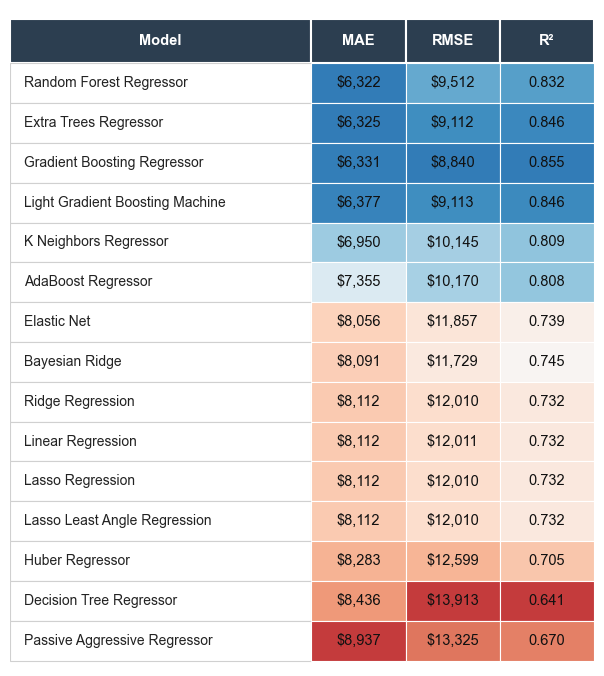

Saved: ../visualizations/results-pycaret-raw.png


In [77]:
render_results_table(
    test_results_df,
    out_path="../visualizations/results-pycaret-raw.png",
    title=None,
)

#### SHAP

In [80]:
x_tr = Path("C:/Users/lodeg/PyCharmMiscProject/x_train (1).csv")
x_te = Path("C:/Users/lodeg/PyCharmMiscProject/x_test (1).csv")
y_tr = Path("C:/Users/lodeg/PyCharmMiscProject/y_train (1).csv")
y_te = Path("C:/Users/lodeg/PyCharmMiscProject/y_test (1).csv")

# Read CSV file into Spark DataFrame
X_train = pd.read_csv(x_tr)
X_test = pd.read_csv(x_te)
y_train = pd.read_csv(y_tr)
y_test = pd.read_csv(y_te)

In [81]:
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"HuberRegressor - MAE: ${mae:,.0f}, RMSE: ${rmse:,.0f}, R2: {r2:.3f}")

HuberRegressor - MAE: $0, RMSE: $0, R2: 0.880


In [59]:
#X_train2 = get_config('X_train')
#X_train_reduced = X_train2.drop(['company_names', 'cars_names', 'Engines', 'fuel_types', 'Price_Category'], axis=1)

In [82]:
from pycaret.regression import setup, compare_models, get_config
explainer = shap.Explainer(best_model,get_config('X_train'))
shap_values = explainer.shap_values(X_test, check_additivity=False)

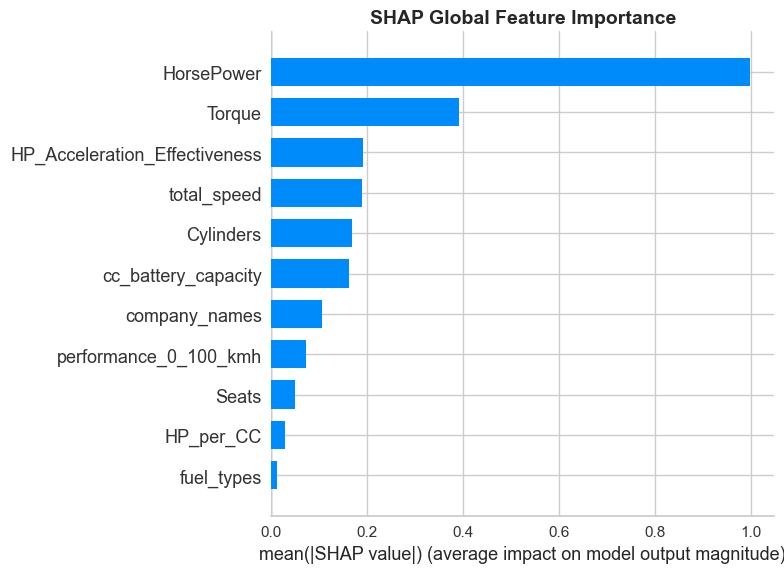

In [83]:
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Global Feature Importance", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Waterfall: Most expensive prediction ($4)


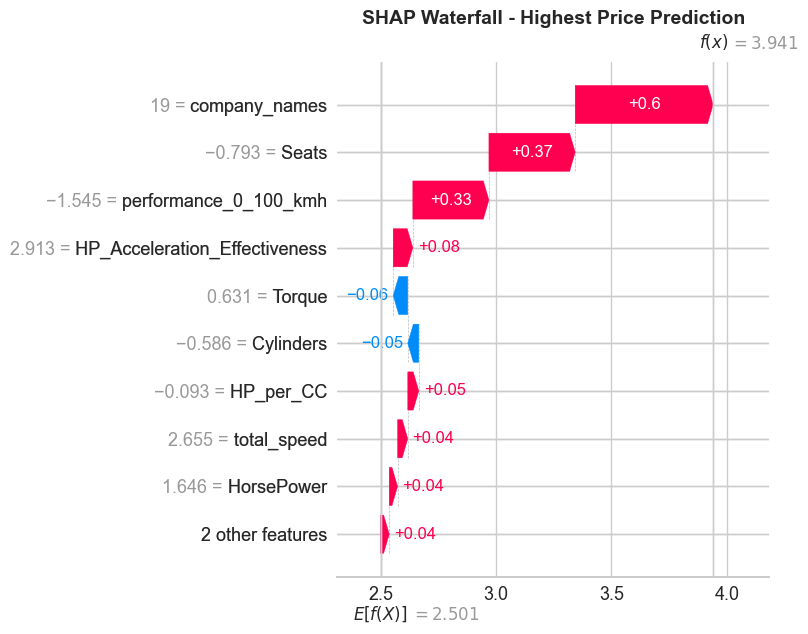

In [84]:
idx_expensive = y_pred.argmax()
idx_cheap = y_pred.argmin()

shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=np.full(len(X_test), explainer.expected_value),
    data=X_test.values,
    feature_names=X_test.columns.tolist(),
)

print(f"Waterfall: Most expensive prediction (${y_pred[idx_expensive]:,.0f})")
shap.plots.waterfall(shap_explanation[idx_expensive], max_display=10, show=False)
plt.title("SHAP Waterfall - Highest Price Prediction", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Waterfall: Cheapest prediction ($-1)


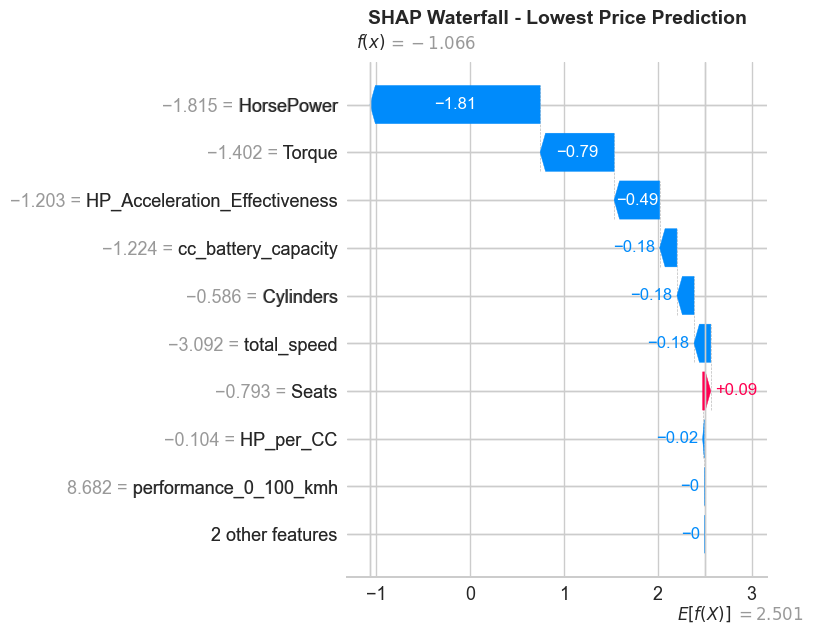

In [85]:
print(f"Waterfall: Cheapest prediction (${y_pred[idx_cheap]:,.0f})")
shap.plots.waterfall(shap_explanation[idx_cheap], max_display=10, show=False)
plt.title("SHAP Waterfall - Lowest Price Prediction", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

#### LIME

In [86]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    mode="regression",
    random_state=42,
)

LIME: Most expensive prediction ($4)


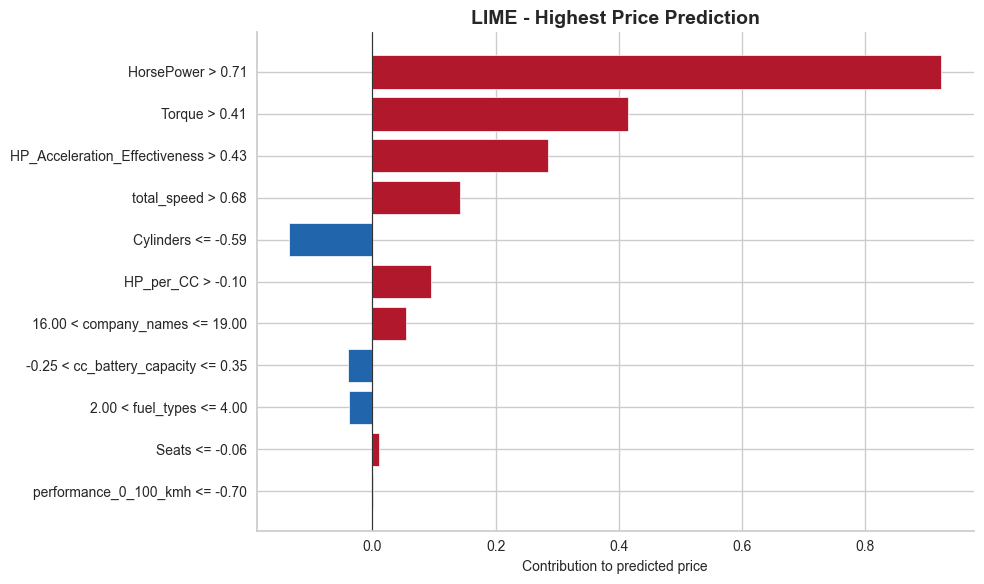

In [88]:
def plot_lime_bars(exp, out_path, title):
    """Render a LIME explanation as a horizontal bar chart in the project palette.

    Positive weights (push prediction up) -> red.
    Negative weights (push prediction down) -> blue.
    """
    items = exp.as_list()
    labels = [label for label, _ in items]
    weights = [weight for _, weight in items]

    order = np.argsort(np.abs(weights))  # smallest to largest, largest at top after barh
    labels = [labels[i] for i in order]
    weights = [weights[i] for i in order]

    red = "#b2182b"
    blue = "#2166ac"
    colors = [red if w > 0 else blue for w in weights]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(len(weights)), weights, color=colors, edgecolor="white", linewidth=0.5)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=10)
    ax.axvline(0, color="#333", linewidth=0.8)
    ax.set_xlabel("Contribution to predicted price", fontsize=10)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()


print(f"LIME: Most expensive prediction (${y_pred[idx_expensive]:,.0f})")
exp_expensive = lime_explainer.explain_instance(
    X_test.iloc[idx_expensive].values,
    best_model.predict,
    num_features=15,
)
plot_lime_bars(
    exp_expensive,
    out_path="C:/Users/lodeg/PyCharmMiscProject/lime-expensive.png",
    title="LIME - Highest Price Prediction",
)

LIME: Cheapest prediction ($-1)


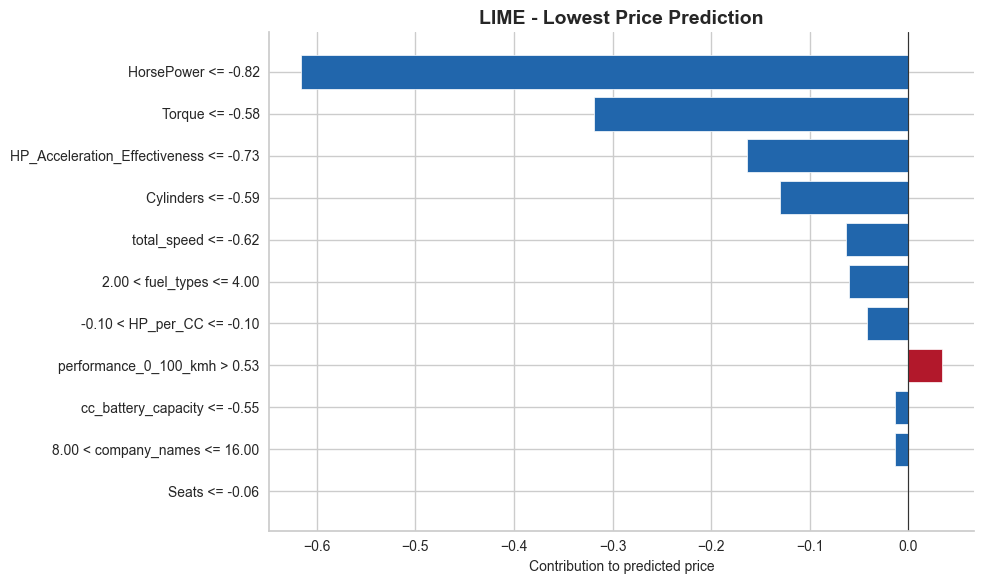

In [90]:
print(f"LIME: Cheapest prediction (${y_pred[idx_cheap]:,.0f})")
exp_cheap = lime_explainer.explain_instance(
    X_test.iloc[idx_cheap].values,
    best_model.predict,
    num_features=15,
)
plot_lime_bars(
    exp_cheap,
    out_path="C:/Users/lodeg/PyCharmMiscProject/lime-cheap.png",
    title="LIME - Lowest Price Prediction",
)

### RAW Data (not used, kept for posterity)


In [24]:
# --- Load featured data (before our preprocessing) ---
df = df_cleaned
print(f"Dataset: {df.shape}")

# Same split as manual pipeline for fair comparison
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print(f"Train: {train_df.shape}, Test: {test_df.shape}")

Dataset: (1043, 11)
Train: (834, 11), Test: (209, 11)


In [25]:
display(df_cleaned)

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FORD,KA+,1.2L Petrol,1200,77,165,10.50,13500,Petrol,5,120
1,TOYOTA,GR SUPRA,I4,2998,382,250,4.10,53900,Petrol,2,500
2,TOYOTA,TOYOTA 86,BOXER-4,1998,205,226,6.40,27000,Petrol,2,205
3,TOYOTA,TOYOTA GR86,BOXER-4,2387,228,226,5.60,30000,Petrol,4,250
4,TOYOTA,TOYOTA LAND CRUISER,V8,5663,381,220,6.70,85000,Diesel,7,500
...,...,...,...,...,...,...,...,...,...,...,...
1038,TOYOTA,Crown Signia,2.5L Hybrid I4,2487,240,180,7.60,45795,Hybrid,5,239
1039,TOYOTA,4Runner (6th Gen),2.4L Turbo I4 (i-FORCE MAX Hybrid),2393,326,180,6.80,50000,Hybrid,7,630
1040,TOYOTA,Corolla Cross,2.0L Gas / 2.0L Hybrid,1987,182,190,8.60,27172,Hybrid,5,200
1041,TOYOTA,C-HR+,1.8L / 2.0L Hybrid,1892,169,180,9.20,33000,Hybrid,5,197


In [26]:
# --- PyCaret setup ---
print("\n" + "=" * 55)
print("PYCARET SETUP")
print("=" * 55)

reg = setup(
    data=train_df,
    target="Cars Prices",
    session_id=42,
    verbose=False,
)



PYCARET SETUP


In [27]:
# --- Compare 20 models ---
print("\n" + "=" * 55)
print("COMPARING 20 MODELS")
print("=" * 55)

best_model = compare_models(n_select=1)
results = pull()
print(results.to_string())


COMPARING 20 MODELS


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
huber,Huber Regressor,8405.2171,148763202.1775,12009.6633,0.7540,0.2558,0.2080,0.0080
par,Passive Aggressive Regressor,14563.4481,423913181.1738,20172.3721,0.2751,0.4935,0.3754,0.0070
knn,K Neighbors Regressor,17210.6160,504642414.5419,22240.8657,0.1586,0.5513,0.5813,0.0100
et,Extra Trees Regressor,17995.9306,533910343.5980,22900.7598,0.1084,0.5573,0.5870,0.0170
lightgbm,Light Gradient Boosting Machine,19076.5513,597063327.2287,24227.1442,0.0012,0.5941,0.6426,0.0630
ada,AdaBoost Regressor,19126.5553,606508627.1073,24409.6839,-0.0131,0.5970,0.6447,0.0110
gbr,Gradient Boosting Regressor,19161.6973,608385024.5741,24444.0441,-0.0157,0.5968,0.6430,0.0160
omp,Orthogonal Matching Pursuit,19193.1912,609939426.7457,24474.1910,-0.0181,0.5978,0.6451,0.0080
rf,Random Forest Regressor,19188.4041,609666700.2613,24471.3438,-0.0181,0.5977,0.6449,0.0210
ridge,Ridge Regression,19196.1391,610037251.8863,24476.2563,-0.0183,0.5978,0.6451,0.0080


                                    Model           MAE           MSE          RMSE            R2   RMSLE          MAPE  TT (Sec)
huber                     Huber Regressor  8.405217e+03  1.487632e+08  1.200966e+04  7.540000e-01  0.2558  2.080000e-01     0.008
par          Passive Aggressive Regressor  1.456345e+04  4.239132e+08  2.017237e+04  2.751000e-01  0.4935  3.754000e-01     0.007
knn                 K Neighbors Regressor  1.721062e+04  5.046424e+08  2.224087e+04  1.586000e-01  0.5513  5.813000e-01     0.010
et                  Extra Trees Regressor  1.799593e+04  5.339103e+08  2.290076e+04  1.084000e-01  0.5573  5.870000e-01     0.017
lightgbm  Light Gradient Boosting Machine  1.907655e+04  5.970633e+08  2.422714e+04  1.200000e-03  0.5941  6.426000e-01     0.063
ada                    AdaBoost Regressor  1.912656e+04  6.065086e+08  2.440968e+04 -1.310000e-02  0.5970  6.447000e-01     0.011
gbr           Gradient Boosting Regressor  1.916170e+04  6.083850e+08  2.444404e+04 -1.570

In [ ]:
# --- Evaluate ALL models on test set ---
print("\n" + "=" * 55)
print("TEST SET EVALUATION (ALL MODELS)")
print("=" * 55)

test_results = []
for idx, row in results.iterrows():
    model_id = idx
    model_name = row["Model"]
    try:
        model = create_model(model_id, verbose=False)
        preds = predict_model(model, data=test_df)
        pred_col = "prediction_label" if "prediction_label" in preds.columns else "Label"
        m_mae = mean_absolute_error(test_df["Cars Prices"], preds[pred_col])
        m_r2 = r2_score(test_df["Cars Prices"], preds[pred_col])
        m_rmse = np.sqrt(((test_df["Cars Prices"] - preds[pred_col]) ** 2).mean())
        test_results.append({"Model": model_name, "MAE": round(m_mae), "RMSE": round(m_rmse), "R2": round(m_r2, 4)})
        print(f"  {model_name:<40} MAE: ${m_mae:>8,.0f}  RMSE: ${m_rmse:>8,.0f}  R2: {m_r2:.4f}")
    except Exception as e:
        print(f"  {model_name:<40} SKIPPED ({e})")

test_results_df = pd.DataFrame(test_results).sort_values("MAE")

In [ ]:
# Best model test metrics
preds = predict_model(best_model, data=test_df)
pred_col = "prediction_label" if "prediction_label" in preds.columns else "Label"
mae = mean_absolute_error(test_df["Cars Prices"], preds[pred_col])
r2 = r2_score(test_df["Cars Prices"], preds[pred_col])
rmse = np.sqrt(((test_df["Cars Prices"] - preds[pred_col]) ** 2).mean())

print(f"\nBest PyCaret model: {type(best_model).__name__}")
print(f"  MAE:  ${mae:,.0f}")
print(f"  RMSE: ${rmse:,.0f}")
print(f"  R2:   {r2:.3f}")